
---

# 🌳 ***`Random Forest in Machine Learning for Data Science`***  

---

## ✅ **What is Random Forest?**  
📌 **Random Forest** is a powerful **ensemble learning algorithm** based on **Bagging (Bootstrap Aggregating)**. It combines multiple **Decision Trees** to improve accuracy and reduce overfitting.  

✅ Suitable for both **classification** and **regression** tasks.  
✅ Robust to **outliers** and **imbalanced data**.  
✅ Highly effective for **large datasets** with many features.  

---

## 🔎 **1. How Does Random Forest Work?**  

### 🔹 **Step 1: Bootstrapping (Data Sampling)**
- Random Forest randomly selects **subsets of data** (with replacement) to train individual Decision Trees.  
- This sampling technique is known as **Bootstrap Sampling**.  

---

### 🔹 **Step 2: Random Feature Selection**
- At each split in a tree, Random Forest randomly selects a **subset of features** instead of considering all features.  
- This introduces **diversity** in trees, reducing correlation between models.  

---

### 🔹 **Step 3: Building Multiple Trees**
- Random Forest builds **multiple Decision Trees** (e.g., 100 or more) using bootstrapped datasets.  

---

### 🔹 **Step 4: Aggregation of Predictions**
- For **classification**, Random Forest uses **majority voting**.  
- For **regression**, it computes the **average prediction** across trees.  

---

### 🔎 **Why Does Random Forest Work Well?**  
✅ Combining multiple Decision Trees reduces **variance**, improving generalization.  
✅ Random feature selection ensures **diversity**, reducing overfitting.  
✅ Bootstrapping creates diverse training data, improving model stability.  

---

## 📊 **2. Random Forest Algorithm Workflow**  

✅ Randomly sample data using **bootstrapping**.  
✅ Randomly select **features** for each tree split.  
✅ Build **multiple Decision Trees** in parallel.  
✅ Aggregate the results via **majority voting** (classification) or **averaging** (regression).  

---

## 📈 **3. Key Hyperparameters in Random Forest**  

| **Hyperparameter** | **Description** | **Recommended Value** |
|---------------------|-----------------|------------------------|
| **`n_estimators`** | Number of trees in the forest. | Start with **100** or **200** |
| **`max_depth`** | Maximum depth of each tree. | Start with `max_depth = 3` to `10` |
| **`min_samples_split`** | Minimum samples required to split a node. | Recommended value = `2`, `5`, or `10` |
| **`min_samples_leaf`** | Minimum samples required in a leaf node. | Recommended value = `1`, `5`, or `10` |
| **`max_features`** | Maximum number of features to consider for each split. | `"sqrt"` (default for classification), `"log2"` |
| **`random_state`** | Ensures reproducibility of results. | Common value = **42** |


## 🏹 **4. Implementing Random Forest in Python**  

### 📁 **Dataset: Iris Flower Classification**  

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,         # Number of trees
    max_depth=4,              # Maximum tree depth
    min_samples_split=5,      # Minimum samples to split
    min_samples_leaf=3,       # Minimum samples per leaf
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45




---

## 🌐 **5. Visualizing Feature Importance**  

📌 Random Forest calculates **feature importance** based on how much a feature improves the model’s performance when used for splitting.  

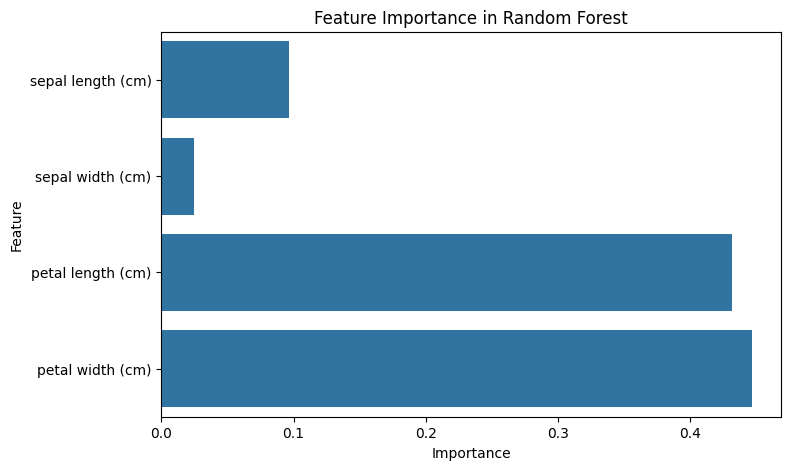

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract Feature Importance
feature_importances = pd.Series(rf_model.feature_importances_, index=iris.feature_names)

# Visualize Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show() 


---

## 🔍 **6. Hyperparameter Tuning with GridSearchCV**  

📌 Fine-tuning hyperparameters helps achieve the **optimal model**. 

In [3]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter Grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

# Grid Search with Cross-Validation
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy: 0.9428571428571428




---

## ⚠️ **7. Handling Overfitting in Random Forest**  

📌 Random Forest can **overfit** if the trees are too deep or too numerous.  

### ✅ **How to Prevent Overfitting?**  
✔️ Use **`max_depth`** to limit tree depth.  
✔️ Increase **`min_samples_split`** or **`min_samples_leaf`** to restrict overfitting.  
✔️ Use fewer trees by adjusting **`n_estimators`** (e.g., 100–200).  
✔️ Use **Cross-Validation** to ensure model generalization.  

---

## 📊 **8. Random Forest vs. Decision Tree**  

| Aspect | **Random Forest** | **Decision Tree** |
|---------|------------------|--------------------|
| **Model Type** | **Ensemble model** (Multiple trees) | **Single tree** |
| **Training Speed** | Slower (due to multiple trees) | Faster |
| **Prediction Speed** | Faster (parallel trees) | Slower (if deep) |
| **Overfitting** | **Less prone** to overfitting | **More prone** to overfitting |
| **Bias-Variance Tradeoff** | **Low bias**, **low variance** | **Low bias**, **high variance** |

✅ Random Forest is generally **more accurate** and **robust** than individual Decision Trees.  

---

## 🚀 **9. Real-World Applications of Random Forest**  

✅ **Healthcare** → Predicting diseases (e.g., diabetes, cancer detection).  
✅ **Finance** → Fraud detection and risk assessment.  
✅ **E-commerce** → Product recommendation systems.  
✅ **Marketing** → Customer segmentation and churn prediction.  
✅ **Image Recognition** → Object detection tasks.  

---

## 🏆 **10. Key Takeaways**  

✅ **Random Forest** is a powerful ensemble method that combines multiple Decision Trees to improve accuracy and robustness.  
✅ It effectively reduces **overfitting** by aggregating multiple models.  
✅ Tuning hyperparameters like **`n_estimators`**, **`max_depth`**, and **`min_samples_split`** enhances performance.  
✅ It works well with both **small** and **large datasets**.  
✅ For highly imbalanced data, use **class_weight='balanced'** to improve performance.  

💡 **Pro Tip:** When faced with noisy data, Random Forest often outperforms other algorithms like SVM or k-NN.  

---

In [17]:
# import libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,mean_squared_error,mean_absolute_error,r2_score

import warnings
warnings.filterwarnings('ignore')

In [18]:
# load the data
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [19]:
# encode the categorical features
le = LabelEncoder()

for i in df.columns:
    if df[i].dtype == 'object' or df[i].dtype == 'category':
        df[i] = le.fit_transform(df[i])

In [20]:
df.sample(4)

,total_bill,tip,sex,smoker,day,time,size
177,14.48,2.00,1,1,2,0,2
118,12.43,1.80,0,0,3,1,2
224,13.42,1.58,1,1,0,1,2
216,28.15,3.00,1,1,1,0,5


In [21]:
# split the data into X and y for classification
X = df.drop('sex',axis=1)
y = df['sex']

In [22]:
# train test split the data
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,
)

In [23]:
# Implement randomforest classifier
model = RandomForestClassifier(
    n_estimators=200,
    criterion='entropy',
    random_state=42,
)

# train the model
model.fit(X_train,y_train)

# predict
y_pred = model.predict(X_test)

# evaluate the model
print(f"\nAccuracy Score: {accuracy_score(y_test,y_pred)}")
print(f"\nConfusion Mtrix: \n{confusion_matrix(y_test,y_pred)}")
print(f"\nClassification Report: \n{classification_report(y_test,y_pred)}")


Accuracy Score: 0.6122448979591837

Confusion Mtrix: 
[[ 7 12]
 [ 7 23]]

Classification Report: 
              precision    recall  f1-score   support

           0       0.50      0.37      0.42        19
           1       0.66      0.77      0.71        30

    accuracy                           0.61        49
   macro avg       0.58      0.57      0.57        49
weighted avg       0.60      0.61      0.60        49



---